In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from functions import *

### This Notebook is intended to serve two purposes: (1) exploration of populations of planets and (2) as a reference for handling and plotting data from the NASA Exoplanet Archive which will be useful for project #2 (and maybe project #1)

Try to figure out what I'm doing in the cell below. Tip: Open the NEA file called 'PS_2024.01.22_04.17.20.csv' with excel and read the descriptions for 'pl_controv_flag', 'pl_rade', 'pl_radelim', 'pl_bmasse', and 'pl_bmasselim'.

In [24]:
pldata = pd.read_csv('datafiles/PS_2024.01.22_04.17.20.csv', skiprows = 100)
pldata = pldata.iloc[np.where(pldata['pl_controv_flag'] == 0)]
#pldata = pldata.iloc[np.where(np.isnan(pldata['pl_rade']) == False)]
#pldata = pldata.iloc[np.where(pldata['pl_radelim'] == 0)]
#pldata = pldata.iloc[np.where(np.isnan(pldata['pl_bmasse']) == False)]
#pldata = pldata.iloc[np.where(pldata['pl_bmasselim'] == 0)]

For your reference:
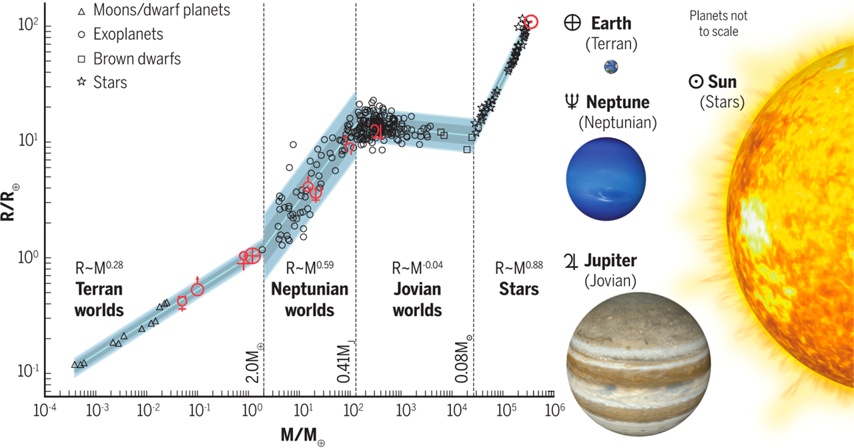

The M-R relationships above are from Chen & Kipping 2016 (https://iopscience.iop.org/article/10.3847/1538-4357/834/1/17/meta). It provides great first-order M-R relationships for the various planet types, but it isn't perfect. For starters, the number of detected planets has almost doubled since 2016. Second, it was created before the discovery of the small-planet radius gap and so there is no differentiation between super-Earths and sub-Neptunes. As a result, it likely underestimates the transition mass between terrestrial (rocky) and Neptunian planets. It also assumes that planets within each class follow the same M-R relationship, which is not the case as we shall see. Regardless, let's use it as a jumping off point and make some general observations. 

The plot below shows a current sample of all detected exoplanets with both a mass and radius measurement (so we may calculate density). The red line shows the Chen & Kipping M-R relationships minus their stellar M-R relationship because, well, stars aren't planets.

With your group discuss the differences between the M-R relationship for rocky, Neptunian, and Jovian planets. Speculate as to what causes these differences.

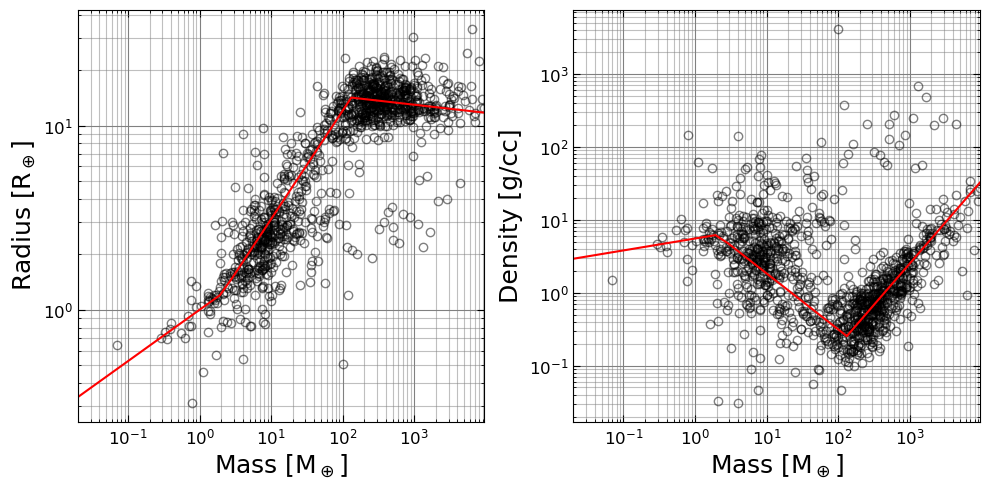

In [27]:
fig, ax = plt.subplots(1,2, figsize = (10,5))
ax[0].plot(pldata['pl_bmasse'], pldata['pl_rade'], 'ko', fillstyle = 'none', alpha = 0.5)
x=np.linspace(min(pldata['pl_bmasse']), max(pldata['pl_bmasse']), 10000)

ax[0].plot(x, 10**chen_kipping(x), 'r-')

ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[0].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 12, top = True, right = True)
ax[0].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 12, top = True, right = True)
ax[0].grid(visible = True, which = 'major', color= 'gray')
ax[0].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)
ax[0].set_xlabel(r'Mass [M$_\oplus$]', fontsize = 18)
ax[0].set_ylabel(r'Radius [R$_\oplus$]', fontsize = 18)
ax[0].set_xlim(min(pldata['pl_bmasse']), max(pldata['pl_bmasse']))


ax[1].plot(pldata['pl_bmasse'], 5.51*pldata['pl_bmasse']/(pldata['pl_rade']**3), 'ko', fillstyle = 'none', alpha = 0.5)

ax[1].plot(x, 5.5*x/((10**chen_kipping(x))**3), 'r-')

ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 12, top = True, right = True)
ax[1].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 12, top = True, right = True)
ax[1].grid(visible = True, which = 'major', color= 'gray')
ax[1].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)
ax[1].set_xlabel(r'Mass [M$_\oplus$]', fontsize = 18)
ax[1].set_ylabel(r'Density [g/cc]', fontsize = 18)
ax[1].set_xlim(min(pldata['pl_bmasse']), max(pldata['pl_bmasse']))



plt.tight_layout()


### Below are three sets of plots without any context. One set is illustrating the transition between rocky planets (terrestrial + Super-Earths) and sub-Neptunes, another is illustrating run-away gas accretion, and one illustrates cold vs hot Jupiters. 

### With your group, try to figure out which is which. Once you've got it figured out, make some obervations about the most striking features in each set of plots and try to see if you can explain what is driving these features.

### If it is annoying to scroll back and forth between the figure sets or you want to see them all side by side, you should be able to click on each and save them as .png files


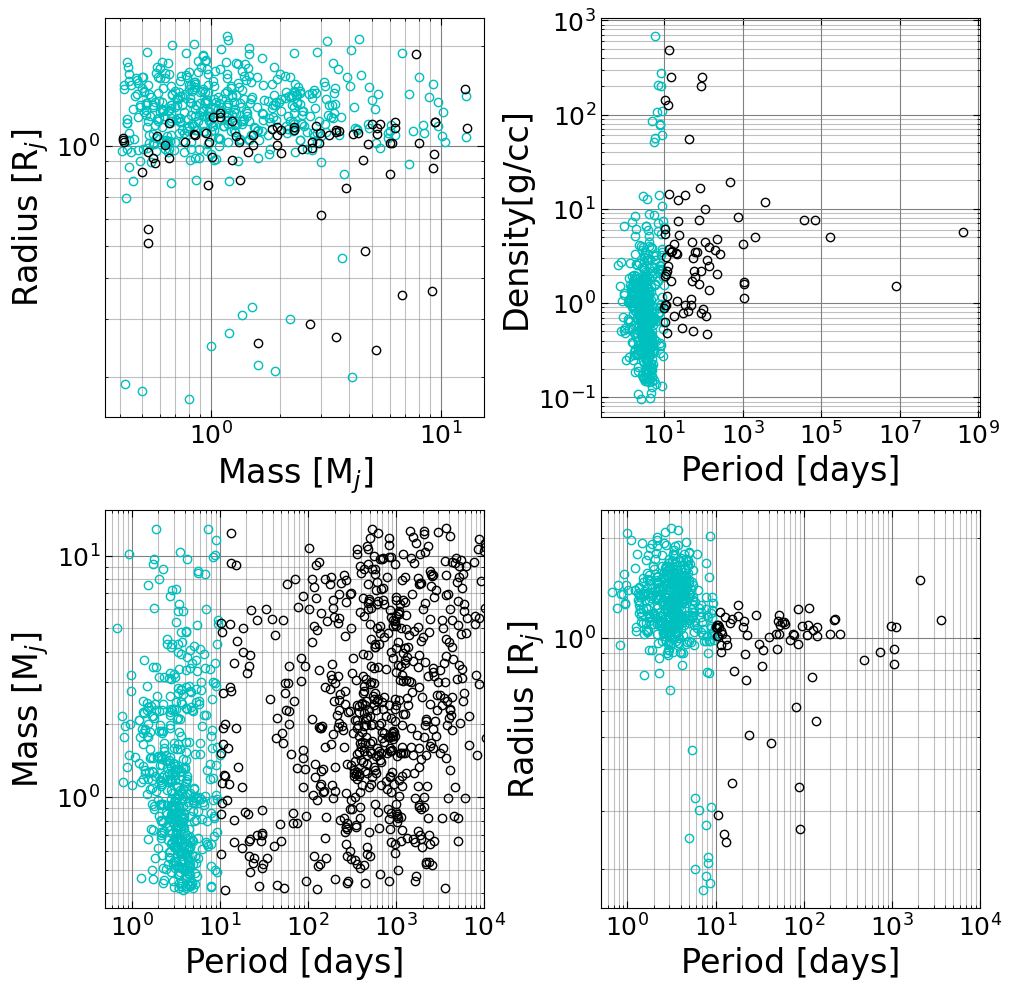

In [30]:
jovian = pldata.iloc[np.where((pldata['pl_bmasse'] >= 0.41*318.0) & (pldata['pl_bmasse']<=13.0*318.0))]
ind1 = np.where(jovian['pl_orbper'] <= 10.0)
ind2 = np.where(jovian['pl_orbper'] > 10.0)

fig, ax = plt.subplots(2, 2, figsize = (10, 10))

ax[1,0].plot(jovian['pl_orbper'].iloc[ind1], jovian['pl_bmasse'].iloc[ind1]/318.0, 'co', fillstyle = 'none')
ax[1,0].plot(jovian['pl_orbper'].iloc[ind2], jovian['pl_bmasse'].iloc[ind2]/318.0, 'ko', fillstyle = 'none')

ax[1,0].set_yscale('log')
ax[1,0].set_xscale('log')
#ax[1,0].plot(4333, 1.0, 'ro', markersize = 10, label = 'Jupiter')
ax[1,0].set_xlim(0.5, 10**4)

ax[1,1].plot(jovian['pl_orbper'].iloc[ind1], jovian['pl_rade'].iloc[ind1]/11.0, 'co', fillstyle = 'none')
ax[1,1].plot(jovian['pl_orbper'].iloc[ind2], jovian['pl_rade'].iloc[ind2]/11.0, 'ko', fillstyle = 'none')

ax[1,1].set_yscale('log')
ax[1,1].set_xscale('log')
#ax[1,1].plot(4333, 1.0, 'ro', markersize = 10, label = 'Jupiter')
ax[1,1].set_xlim(0.5, 10**4)


ax[0,1].plot(jovian['pl_orbper'].iloc[ind1], 5.51*jovian['pl_bmasse'].iloc[ind1]/(jovian['pl_rade'].iloc[ind1]**3), 'co', fillstyle = 'none')
ax[0,1].plot(jovian['pl_orbper'].iloc[ind2], 5.51*jovian['pl_bmasse'].iloc[ind2]/(jovian['pl_rade'].iloc[ind2]**3), 'ko', fillstyle = 'none')

ax[0,1].set_yscale('log')
ax[0,1].set_xscale('log')
#ax[0,1].plot(4333, 1.33, 'ro', markersize = 10, label = 'Jupiter')
#ax[0,1].set_xlim(0.5, 10**4)

ax[1,0].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 18, top = True, right = True)
ax[1,0].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 19, top = True, right = True)
ax[1,0].grid(visible = True, which = 'major', color= 'gray')
ax[1,0].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)

ax[1,1].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 18, top = True, right = True)
ax[1,1].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 18, top = True, right = True)
ax[1,1].grid(visible = True, which = 'major', color= 'gray')
ax[1,1].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)

ax[0,1].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 18, top = True, right = True)
ax[0,1].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 18, top = True, right = True)
ax[0,1].grid(visible = True, which = 'major', color= 'gray')
ax[0,1].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)

ax[0,0].plot(jovian['pl_bmasse'].iloc[ind1]/318.0, jovian['pl_rade'].iloc[ind1]/11.0, 'co', fillstyle = 'none')
ax[0,0].plot(jovian['pl_bmasse'].iloc[ind2]/318.0, jovian['pl_rade'].iloc[ind2]/11.0, 'ko', fillstyle = 'none')

ax[0,0].set_yscale('log')
ax[0,0].set_xscale('log')
#ax[0,0].plot(1.0, 1.0, 'ro', markersize = 10, label = 'Jupiter')

ax[0,0].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 18, top = True, right = True)
ax[0,0].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 18, top = True, right = True)
ax[0,0].grid(visible = True, which = 'major', color= 'gray')
ax[0,0].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)


ax[0,0].set_xlabel(r'Mass [M$_j$]', fontsize = 24)
ax[0,0].set_ylabel(r'Radius [R$_j$]', fontsize = 24)

ax[1,0].set_ylabel(r'Mass [M$_j$]', fontsize = 24)
ax[1,0].set_xlabel(r'Period [days]', fontsize = 24)


ax[1,1].set_ylabel(r'Radius [R$_j$]', fontsize = 24)
ax[1,1].set_xlabel(r'Period [days]', fontsize = 24)


ax[0,1].set_ylabel(r'Density[g/cc]', fontsize = 24)
ax[0,1].set_xlabel(r'Period [days]', fontsize = 24)


plt.tight_layout()

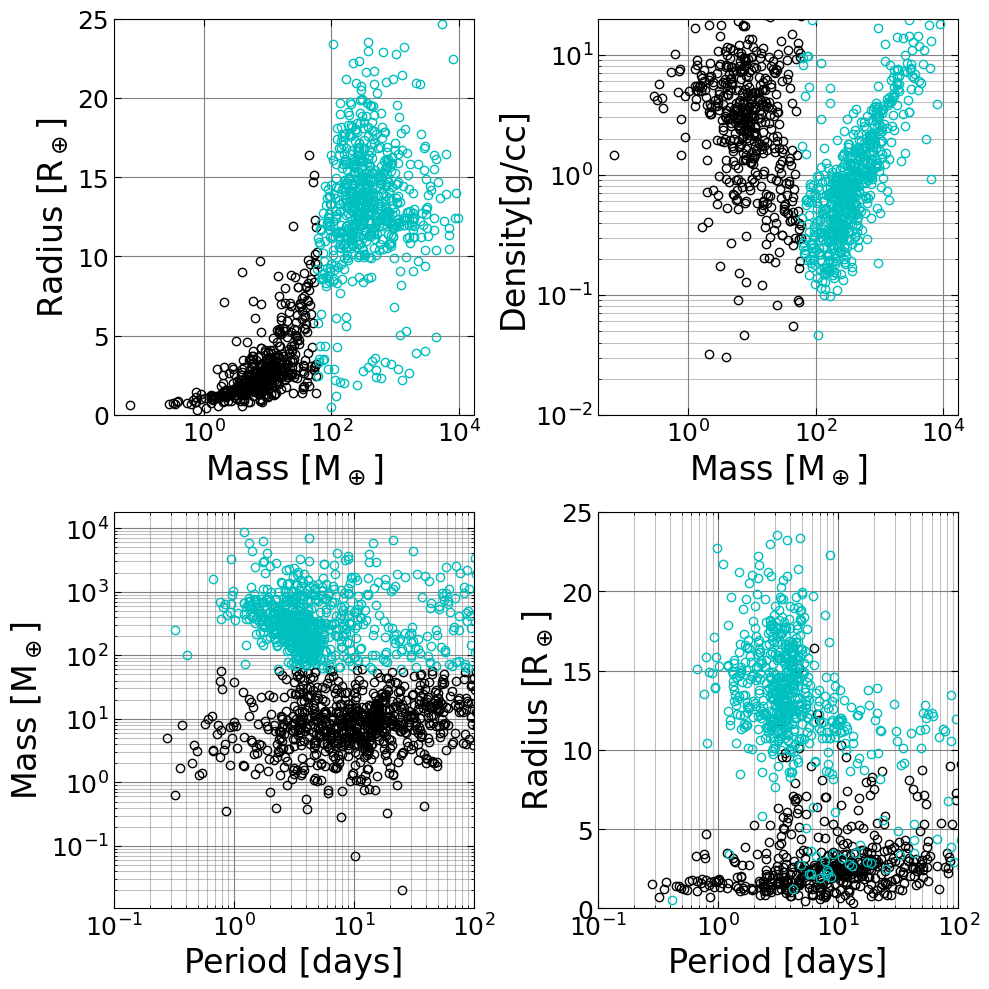

In [32]:
#pldata = pldata.iloc[np.where((pldata['pl_bmasse'] < 0.41*318.0))]
fig, ax = plt.subplots(2, 2, figsize = (10, 10))

mcrit = 60.0
ind1 = np.where(pldata['pl_bmasse'] <= mcrit)
ind2 = np.where(pldata['pl_bmasse'] > mcrit)

alpha = 1.0
ax[1,0].plot(pldata['pl_orbper'].iloc[ind1], pldata['pl_bmasse'].iloc[ind1], 'ko', fillstyle = 'none', alpha = alpha)
ax[1,0].plot(pldata['pl_orbper'].iloc[ind2], pldata['pl_bmasse'].iloc[ind2], 'co', fillstyle = 'none', alpha = alpha)

ax[1,0].set_yscale('log')
ax[1,0].set_xscale('log')


ax[1,1].plot(pldata['pl_orbper'].iloc[ind1], pldata['pl_rade'].iloc[ind1], 'ko', fillstyle = 'none', alpha = alpha)
ax[1,1].plot(pldata['pl_orbper'].iloc[ind2], pldata['pl_rade'].iloc[ind2], 'co', fillstyle = 'none', alpha = alpha)

#ax[1,1].set_yscale('log')
ax[1,1].set_xscale('log')



ax[0,1].plot(pldata['pl_bmasse'].iloc[ind1], 5.51*pldata['pl_bmasse'].iloc[ind1]/(pldata['pl_rade'].iloc[ind1]**3), 'ko', fillstyle = 'none', alpha = alpha)
ax[0,1].plot(pldata['pl_bmasse'].iloc[ind2], 5.51*pldata['pl_bmasse'].iloc[ind2]/(pldata['pl_rade'].iloc[ind2]**3), 'co', fillstyle = 'none', alpha = alpha)

#ax[0,1].set_yscale('log')
ax[0,1].set_xscale('log')



ax[1,0].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 18, top = True, right = True)
ax[1,0].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 19, top = True, right = True)
ax[1,0].grid(visible = True, which = 'major', color= 'gray')
ax[1,0].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)

ax[1,1].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 18, top = True, right = True)
ax[1,1].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 18, top = True, right = True)
ax[1,1].grid(visible = True, which = 'major', color= 'gray')
ax[1,1].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)

ax[0,1].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 18, top = True, right = True)
ax[0,1].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 18, top = True, right = True)
ax[0,1].grid(visible = True, which = 'major', color= 'gray')
ax[0,1].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)


ax[1,0].set_ylabel(r'Mass [M$_\oplus$]', fontsize = 24)
ax[1,0].set_xlabel(r'Period [days]', fontsize = 24)


ax[1,1].set_ylabel(r'Radius [R$_\oplus$]', fontsize = 24)
ax[1,1].set_xlabel(r'Period [days]', fontsize = 24)


ax[0,1].set_ylabel(r'Density[g/cc]', fontsize = 24)
ax[0,1].set_xlabel(r'Mass [M$_\oplus$]', fontsize = 24)

ax[1,1].set_xlim(0.1, 100)
ax[1,0].set_xlim(0.1, 100)
#ax[0,1].set_xlim(0.1, 100)



ax[0,0].plot(pldata['pl_bmasse'].iloc[ind1], pldata['pl_rade'].iloc[ind1], 'ko', fillstyle = 'none', alpha = alpha)
ax[0,0].plot(pldata['pl_bmasse'].iloc[ind2], pldata['pl_rade'].iloc[ind2], 'co', fillstyle = 'none', alpha = alpha)
#ax[0,0].set_yscale('log')
ax[0,0].set_xscale('log')

ax[0,0].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 18, top = True, right = True)
ax[0,0].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 18, top = True, right = True)
ax[0,0].grid(visible = True, which = 'major', color= 'gray')
ax[0,0].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)
ax[0,0].set_xlabel(r'Mass [M$_\oplus$]', fontsize = 24)
ax[0,0].set_ylabel(r'Radius [R$_\oplus$]', fontsize = 24)

ax[0,0].set_ylim(0, 25)
ax[1,1].set_ylim(0, 25)

#ax[1,0].axhline(30.0)
ax[0,1].set_ylim(0.01, 20)
ax[0,1].set_yscale('log')

plt.tight_layout()


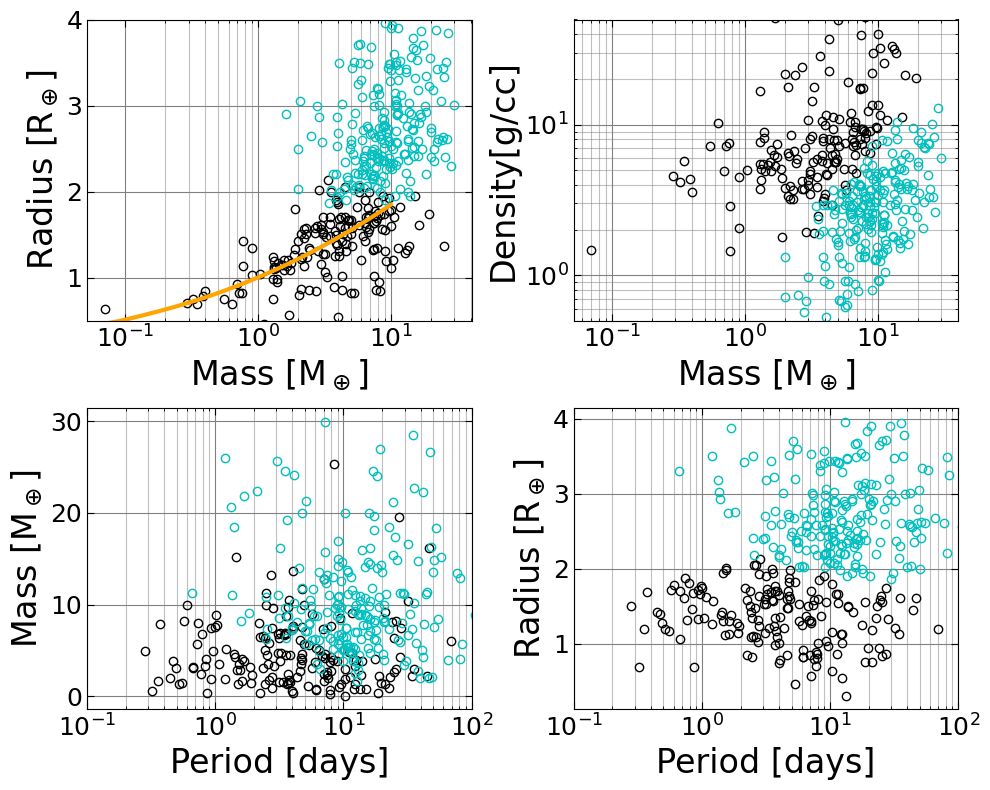

In [36]:
se_sn = pldata.iloc[np.where((pldata['pl_rade'] < 4.0) & (pldata['pl_bmasse']<30))]
#se_sn = se_sn.iloc[np.where((se_sn['pl_radeerr1']/se_sn['pl_rade']) <= 0.3)]
#se_sn = se_sn.iloc[np.where((se_sn['pl_bmasseerr1']/se_sn['pl_bmasse']) <= 0.3)]

fig, ax = plt.subplots(2, 2, figsize = (10, 8))

import scipy.interpolate as si
elike = pd.read_csv('datafiles/elike.csv')
elike = si.interp1d(elike['mass'], elike['radius'], fill_value = 'extrapolate')

ind1 = np.where(se_sn['pl_rade'] < 10**(-0.09*np.log10(se_sn['pl_orbper']) + 0.37))
ind2 = np.where(se_sn['pl_rade'] > 10**(-0.09*np.log10(se_sn['pl_orbper']) + 0.37))


alpha = 1.0
ax[1,0].plot(se_sn['pl_orbper'].iloc[ind1], se_sn['pl_bmasse'].iloc[ind1], 'ko', fillstyle = 'none', alpha = alpha)
ax[1,0].plot(se_sn['pl_orbper'].iloc[ind2], se_sn['pl_bmasse'].iloc[ind2], 'co', fillstyle = 'none', alpha = alpha)

#ax[1,0].set_yscale('log')
ax[1,0].set_xscale('log')


ax[1,1].plot(se_sn['pl_orbper'].iloc[ind1], se_sn['pl_rade'].iloc[ind1], 'ko', fillstyle = 'none', alpha = alpha)
ax[1,1].plot(se_sn['pl_orbper'].iloc[ind2], se_sn['pl_rade'].iloc[ind2], 'co', fillstyle = 'none', alpha = alpha)

#ax[1,1].set_yscale('log')
ax[1,1].set_xscale('log')



ax[0,1].plot(se_sn['pl_bmasse'].iloc[ind1], 5.51*se_sn['pl_bmasse'].iloc[ind1]/(se_sn['pl_rade'].iloc[ind1]**3), 'ko', fillstyle = 'none', alpha = alpha)
ax[0,1].plot(se_sn['pl_bmasse'].iloc[ind2], 5.51*se_sn['pl_bmasse'].iloc[ind2]/(se_sn['pl_rade'].iloc[ind2]**3), 'co', fillstyle = 'none', alpha = alpha)

ax[0,1].set_yscale('log')
ax[0,1].set_xscale('log')



ax[1,0].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 18, top = True, right = True)
ax[1,0].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 19, top = True, right = True)
ax[1,0].grid(visible = True, which = 'major', color= 'gray')
ax[1,0].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)

ax[1,1].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 18, top = True, right = True)
ax[1,1].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 18, top = True, right = True)
ax[1,1].grid(visible = True, which = 'major', color= 'gray')
ax[1,1].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)

ax[0,1].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 18, top = True, right = True)
ax[0,1].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 18, top = True, right = True)
ax[0,1].grid(visible = True, which = 'major', color= 'gray')
ax[0,1].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)

ax[0,0].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 18, top = True, right = True)
ax[0,0].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 18, top = True, right = True)
ax[0,0].grid(visible = True, which = 'major', color= 'gray')
ax[0,0].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)

ax[1,0].set_ylabel(r'Mass [M$_\oplus$]', fontsize = 24)
ax[1,0].set_xlabel(r'Period [days]', fontsize = 24)


ax[1,1].set_ylabel(r'Radius [R$_\oplus$]', fontsize = 24)
ax[1,1].set_xlabel(r'Period [days]', fontsize = 24)


ax[0,1].set_ylabel(r'Density[g/cc]', fontsize = 24)
ax[0,1].set_xlabel(r'Mass [M$_\oplus$]', fontsize = 24)

ax[0,0].plot(se_sn['pl_bmasse'].iloc[ind1], se_sn['pl_rade'].iloc[ind1], 'ko', fillstyle = 'none', alpha = alpha)
ax[0,0].plot(se_sn['pl_bmasse'].iloc[ind2], se_sn['pl_rade'].iloc[ind2], 'co', fillstyle = 'none', alpha = alpha)
ax[0,0].set_xscale('log')
#ax[0,0].set_yscale('log')
ax[0,0].set_xticks([0.1, 1.0, 10.0, 100.0])
ax[0,0].set_xticks( [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 
                     2,3,4,5,6,7,8,9,
                     20.0, 30.0, 40., 50., 60, 70, 80, 90], minor = True)


ax[1,1].set_xlim(0.1, 100)
ax[1,0].set_xlim(0.1, 100)
#ax[0,1].set_xlim(0.1, 100)


ax[0,0].set_xlabel(r'Mass [M$_\oplus$]', fontsize = 24)
ax[0,0].set_ylabel(r'Radius [R$_\oplus$]', fontsize = 24)

x = np.linspace(min(se_sn['pl_bmasse']), 10.0, 1000)
ax[0,0].plot(x, elike(x), '-', color = 'orange', lw = 3)


ax[0,1].set_ylim(0.5, 50)

ax[0,0].set_ylim(0.5, 4.0)


plt.tight_layout()